# Week 7 - Machine Learning Classification
## Exercise 16: Now we can try a different dataset, and test the whole pipeline on it. The dataset for this exercise is iris dataset Iris - UCI Machine Learning Repository.

In [12]:
# Importing the libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [13]:
# Importing the dataset via sklearn lib
from sklearn.datasets import load_iris

In [14]:
# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names 
target_names = iris.target_names

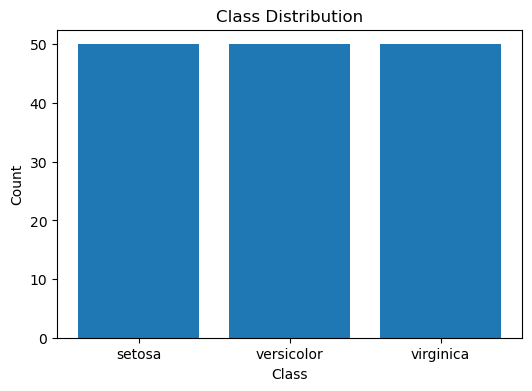

In [15]:
# Visualizing the classes distribution 
plt.figure(figsize=(6, 4)) 
plt.bar(target_names, np.bincount(y)) 
plt.xlabel('Class') 
plt.ylabel('Count') 
plt.title('Class Distribution') 
plt.show()

In [16]:
# Splitting the dataset into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Feature scaling 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [18]:
# Fitting logistic regression to the training set 
classifier = LogisticRegression(random_state=0) 
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [19]:
# Predicting the test set results 
y_pred = classifier.predict(X_test)

In [20]:
# Evaluating the model 
print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


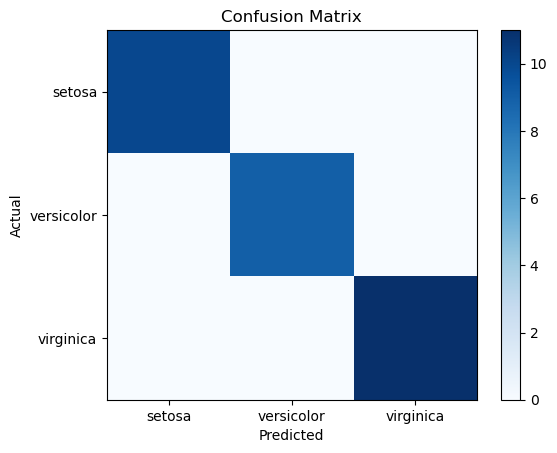

In [21]:
# Plotting the confusion matrix 
conf_matrix = confusion_matrix(y_test, y_pred) 
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest') 
plt.title('Confusion Matrix') 
plt.colorbar() 
tick_marks = np.arange(3) 
plt.xticks(tick_marks, target_names) 
plt.yticks(tick_marks, target_names) 
plt.xlabel('Predicted') 
plt.ylabel('Actual') 
plt.show()

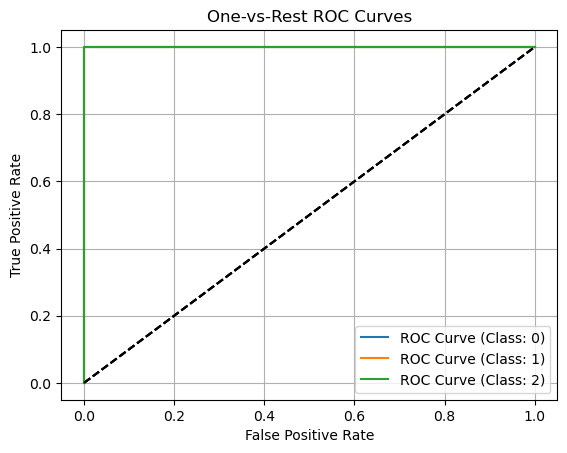

In [32]:
# Get predicted probabilities for all classes
y_pred_proba = classifier.predict_proba(X_test)

# Loop through each class and plot ROC curve
for i, class_label in enumerate(classifier.classes_):
  fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, i], pos_label=class_label)
  plt.plot(fpr, tpr, label=f'ROC Curve (Class: {class_label})')
  plt.plot([0, 1], [0, 1], 'k--')  # Random guess line

# Configure and display the plot
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('One-vs-Rest ROC Curves')
plt.grid(True)
plt.legend()
plt.show()

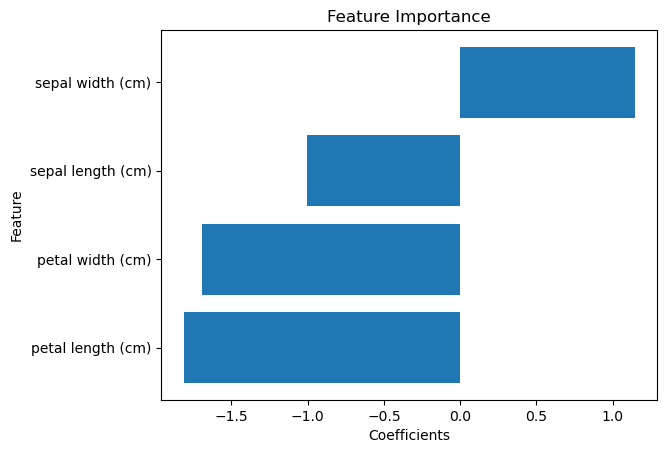

In [24]:
# Plotting feature importance 
coefficients = classifier.coef_[0] 
sorted_indices = np.argsort(coefficients) 

# Create an empty list to store feature names in sorted order
sorted_feature_names = []
for idx in sorted_indices:
  sorted_feature_names.append(feature_names[idx])

plt.barh(range(len(coefficients)), coefficients[sorted_indices], 
          tick_label=sorted_feature_names)

plt.title('Feature Importance') 
plt.xlabel('Coefficients') 
plt.ylabel('Feature') 
plt.show()